##### EDA: understanding the data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
global_cyber_data = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")

In [3]:
global_cyber_data.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [4]:
global_cyber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [5]:
global_cyber_data.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [6]:
global_cyber_data.head(5)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


##### feature engineering

In [7]:
#creating bins for the important metric in the dataset: incident resolution time
global_cyber_data["IncidentResolutionLevels"]=pd.cut(
    global_cyber_data["Incident Resolution Time (in Hours)"],
    bins=[0,12,36,72],
    labels=["Fast","Moderate","Slow"]
)

In [8]:
global_cyber_data.head(5)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),IncidentResolutionLevels
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63,Slow
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71,Slow
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20,Moderate
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7,Fast
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68,Slow


In [9]:
#sorting the table without the index
global_cyber_data=global_cyber_data.sort_values("Year").reset_index(drop=True)

In [10]:
global_cyber_data.head(5)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),IncidentResolutionLevels
0,Germany,2015,Man-in-the-Middle,IT,54.54,775866,Insider,Weak Passwords,AI-based Detection,69,Slow
1,USA,2015,SQL Injection,Retail,26.98,763017,Insider,Social Engineering,Firewall,24,Moderate
2,Russia,2015,Ransomware,Retail,84.08,71334,Unknown,Unpatched Software,AI-based Detection,26,Moderate
3,Germany,2015,DDoS,Retail,7.84,323011,Nation-state,Social Engineering,Encryption,25,Moderate
4,India,2015,Man-in-the-Middle,Banking,97.28,694308,Nation-state,Weak Passwords,VPN,66,Slow


IncidentResolutionLevels  Fast  Moderate  Slow  Total
Target Industry                                      
Total                      478      1021  1501   3000
IT                          67       180   231    478
Banking                     71       154   220    445
Healthcare                  69       156   204    429
Retail                      65       140   218    423
Education                   72       136   211    419
Government                  67       129   207    403
Telecommunications          67       126   210    403


<Axes: xlabel='count', ylabel='Target Industry'>

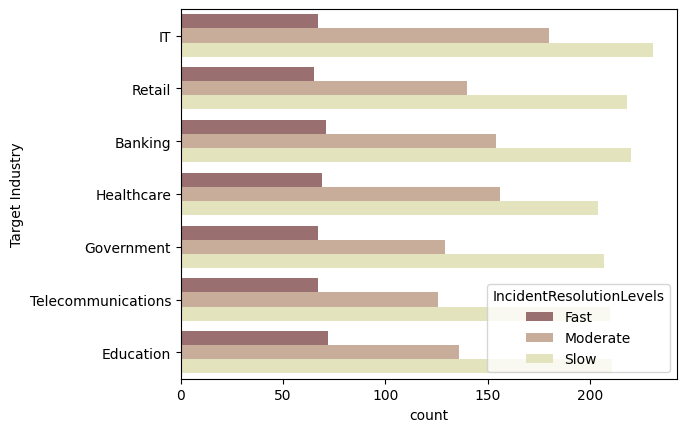

In [123]:
incident_resolution_table = pd.crosstab(
    global_cyber_data["Target Industry"],
    global_cyber_data["IncidentResolutionLevels"],
    margins=True,
    margins_name="Total",
).sort_values("Total", ascending=False)
print(incident_resolution_table)

sns.countplot(data=global_cyber_data, y="Target Industry", hue="IncidentResolutionLevels", palette="pink")

##### q1. most targeted industry

Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Government            403
Telecommunications    403
Name: count, dtype: int64


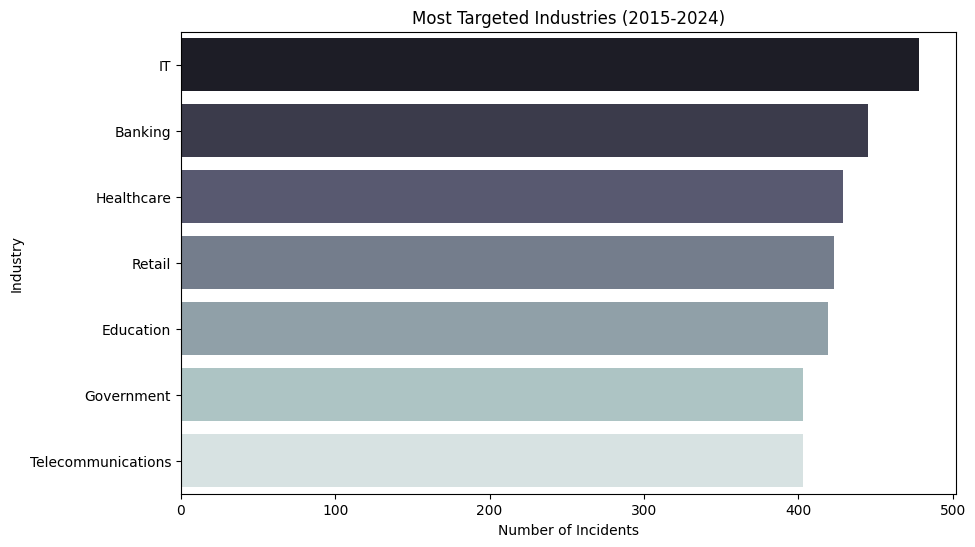

In [119]:
industry = global_cyber_data["Target Industry"].value_counts()
print(industry)

plt.figure(figsize=(10,6))
sns.barplot(x=industry.values, y=industry.index, hue=industry.index, palette="bone")
plt.title("Most Targeted Industries (2015-2024)")
plt.xlabel("Number of Incidents")
plt.ylabel("Industry")
plt.show()

##### q2. most occurring attack type

Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64


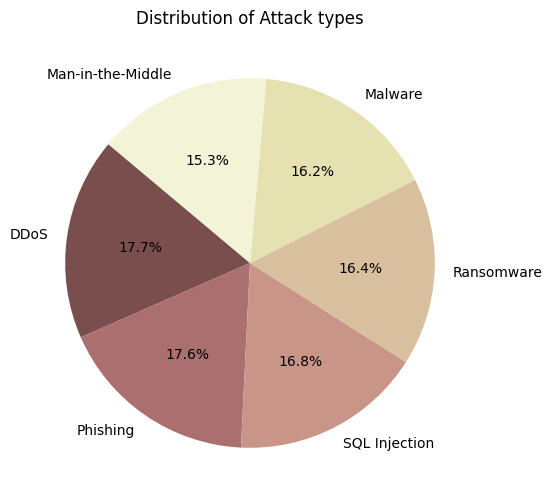

In [99]:
attacks = global_cyber_data["Attack Type"].value_counts()
print(attacks)

plt.figure(figsize=(10,6))
plt.pie(attacks, labels=attacks.index, startangle=140, autopct="%1.1f%%", colors=sns.color_palette("pink"))
plt.title("Distribution of Attack types")
plt.show()

##### q3. evolution of threats over the years

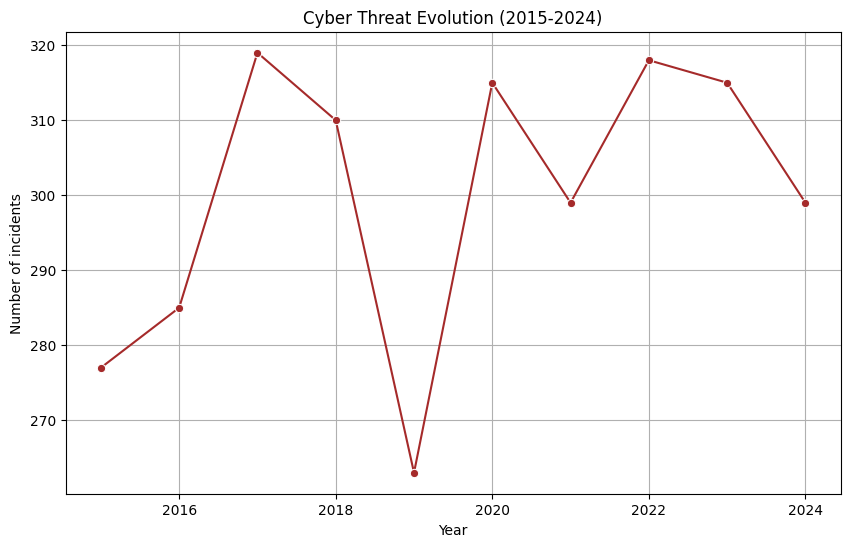

In [100]:
year_trend = global_cyber_data.groupby("Year").size()

plt.figure(figsize=(10,6))
sns.lineplot(x=year_trend.index, y=year_trend.values, marker="o", color="brown")
plt.title("Cyber Threat Evolution (2015-2024)")
plt.grid(True)
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.show()

##### q4. Highest users attacked per country per year

Year           2015      2016      2017      2018      2019      2020  \
Country                                                                 
Australia  11071355  16522223  15829968  17636180  12995593  11011231   
Brazil     14625687  12412484  19398597  16441947  15514625  15196610   
China      14315760  14958638   9732124  11024271  12943762  13332023   
France     15389278  13274133  19444809  16231968  15916554  19716201   
Germany    11814325  18645691  16239690  15503497   9420383  12919945   
India      16632245  12085161  14927191  13355822  14398125  19110451   
Japan      13971922   7457248  18421875  15287249  10207336  17114862   
Russia     15601300  11109717  15475371  15885557  15758126  16314224   
UK         16071806  17281052  14937244  13163819  14851883  17029565   
USA        11799492  20288237  17401011  17244644   8206541  17291649   

Year           2021      2022      2023      2024  
Country                                            
Australia  12383861

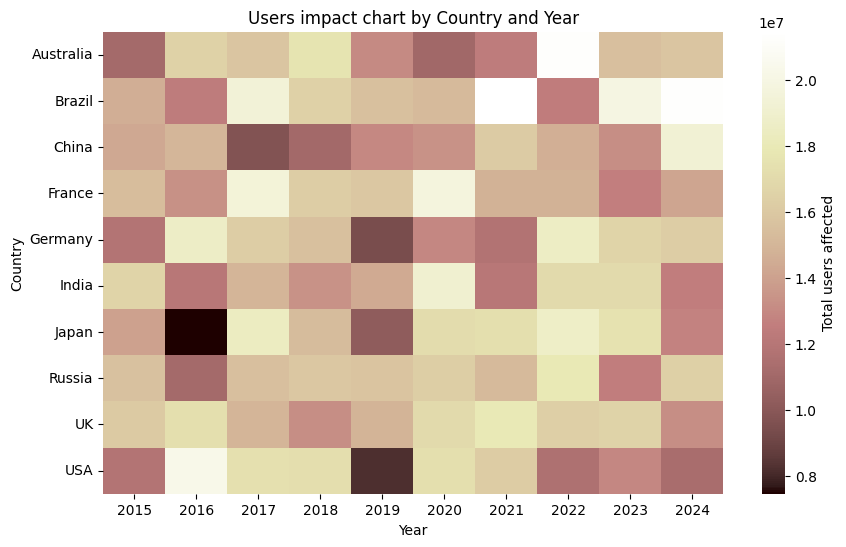

In [116]:
table = global_cyber_data.pivot_table(
    values="Number of Affected Users",
    index="Country",
    columns="Year",
    aggfunc="sum"
)
print(table)

plt.figure(figsize=(10,6))
sns.heatmap(table, annot=False, cmap="pink", cbar_kws={"label":"Total users affected"})
plt.title("Users impact chart by Country and Year")
plt.show()

##### q5. Country most vulnerable based on financial loss

Country
UK           16502.99
Germany      15793.24
Brazil       15782.62
Australia    15403.00
Japan        15197.34
France       14972.28
USA          14812.12
Russia       14734.73
India        14566.12
China        13714.47
Name: Financial Loss (in Million $), dtype: float64


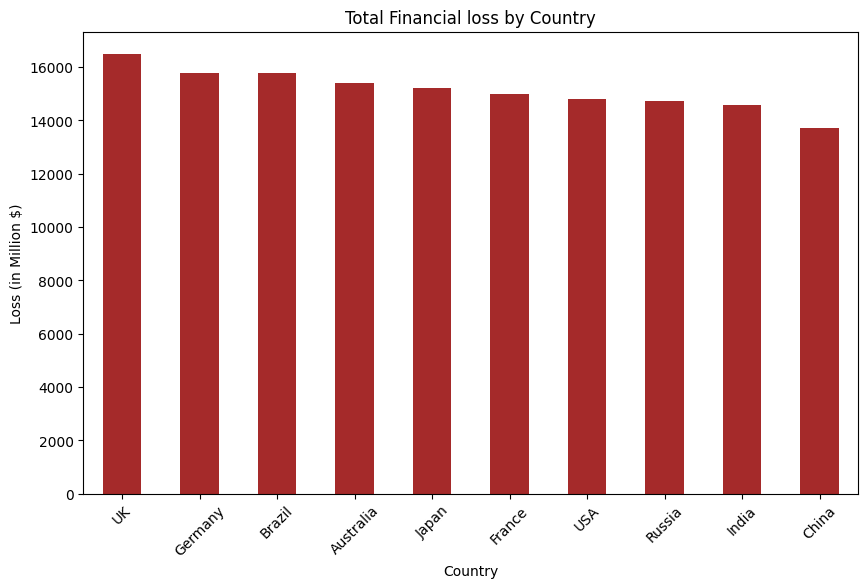

In [118]:
vulnerability = global_cyber_data.groupby("Country")["Financial Loss (in Million $)"].sum().sort_values(ascending=False)
print(vulnerability)

plt.figure(figsize=(10,6))
vulnerability.plot(kind="bar",color="brown")
plt.title("Total Financial loss by Country")
plt.xticks(rotation=45)
plt.ylabel("Loss (in Million $)")
plt.show()

In [126]:
global_cyber_data.to_csv("cyberthreat_data.csv",index=False)